<a href="https://www.kaggle.com/code/pavankumar960/f1-analytics-pit-stop-prediction-smote?scriptVersionId=309828761" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Project Overview

*Objective*

- Predict `PitNextLap` (binary classification) using high-fidelity F1 race telemetry and engineered features.
- Analyze the impact of tyre life and compound types on strategic pit window timing, incorporating core F1 sporting regulations (e.g., the mandatory requirement to use at least two different dry tyre compounds during a race to avoid disqualification).
- Account for common strategic practices that heavily influence pit decisions, such as:
  - **The Undercut/Overcut:** Pitting earlier or later than a rival to exploit fresh tyre pace or clean air.
  - **Capitalizing on Race Neutralizations:** Taking "cheap" pit stops during Safety Car (SC) or Virtual Safety Car (VSC) periods where the time loss relative to the pack is minimized.
  - **Traffic Management:** Timing pit exits to drop the driver into "clean air" rather than getting stuck behind slower cars.
- Optimize pit stop detection by filtering race-anomalies (Safety Cars/Accidents) and accounting for class imbalance using SMOTE.

In [1]:
# Basic Libs
import numpy as np 
import pandas as pd 

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (18, 12)

# Data Acquisition

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v3.csv")

# Initial Data Profiling & Structural Analysis

In [3]:
df.shape

(79511, 16)

In [4]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000,79511.000000
mean,30.755531,2.038699,14.840437,9.797412,91.896198,2024.026738,-0.271768,-29.321900,0.235112,0.237011,0.439047,0.399587,0.002377
std,18.214034,0.948782,10.539932,5.424086,36.568538,0.807906,49.968165,74.806135,0.424072,0.425252,0.260152,0.266094,3.751109
min,1.000000,1.000000,1.000000,1.000000,67.012000,2023.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,81.623000,2023.000000,-6.023500,-48.465000,0.000000,0.000000,0.217949,0.177778,-1.000000
50%,30.000000,2.000000,13.000000,10.000000,90.542000,2024.000000,-0.025000,-20.874000,0.000000,0.000000,0.428571,0.350649,0.000000
75%,45.000000,3.000000,21.000000,14.000000,98.747000,2025.000000,3.556500,-4.275500,0.000000,0.000000,0.641026,0.588235,1.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [5]:
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [6]:
df.isnull().sum()

Driver                    0
LapNumber                 0
Compound                  0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
Race                      0
Year                      0
LapTime_Delta             0
Cumulative_Degradation    0
PitStop                   0
PitNextLap                0
RaceProgress              0
Normalized_TyreLife       0
Position_Change           0
dtype: int64

In [7]:
dff = df.duplicated().sum()
print(dff)

0


In [8]:
print("Compounds present:", df['Compound'].unique())
print("Number of unique Races:", df['Race'].nunique())
print("Number of unique Drivers:", df['Driver'].nunique())

Compounds present: ['MEDIUM' 'HARD' 'SOFT' 'INTERMEDIATE' 'WET']
Number of unique Races: 25
Number of unique Drivers: 28


In [9]:
print("Target Variable (PitNextLap) Distribution:")
print(df['PitNextLap'].value_counts(normalize=True) * 100)

Target Variable (PitNextLap) Distribution:
PitNextLap
0    76.298877
1    23.701123
Name: proportion, dtype: float64


In [10]:
print("Skewness of LapTime (s):", df['LapTime (s)'].skew())

Skewness of LapTime (s): 56.87203051999305


# Data Cleaning 

## Telemetry Filtering

In [11]:
df_cleaned = df.copy()
median_lap = df_cleaned['LapTime (s)'].median()
outlier_threshold = median_lap * 1.5
df_cleaned = df_cleaned[df_cleaned['LapTime (s)'] < outlier_threshold]
print(f"Removed {len(df) - len(df_cleaned)} outlier laps (Safety Cars/Accidents).")

Removed 937 outlier laps (Safety Cars/Accidents).


In [12]:
# Removing outliers in Cumulative_Degradation using the IQR method
Q1 = df_cleaned['Cumulative_Degradation'].quantile(0.25)
Q3 = df_cleaned['Cumulative_Degradation'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

initial_len = len(df_cleaned)
df_cleaned = df_cleaned[(df_cleaned['Cumulative_Degradation'] >= lower_bound) & 
                        (df_cleaned['Cumulative_Degradation'] <= upper_bound)]

print(f"Removed {initial_len - len(df_cleaned)} outliers from Cumulative_Degradation.")

Removed 13694 outliers from Cumulative_Degradation.


## Noise Reduction

In [13]:
cols_to_drop = ['PitStop', 'Normalized_TyreLife', 'Year'] 
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

print(f"Remaining columns for analysis: {df_cleaned.columns.tolist()}")

Remaining columns for analysis: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'LapTime_Delta', 'Cumulative_Degradation', 'PitNextLap', 'RaceProgress', 'Position_Change']


**Observation**

The dataset contains 16 initial features. Data cleaning focused on removing 654 telemetry outliers and dropping redundant normalized features to prevent Multicollinearity, ensuring the model prioritizes physical degradation over mathematical scaling.

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Feature Distributions

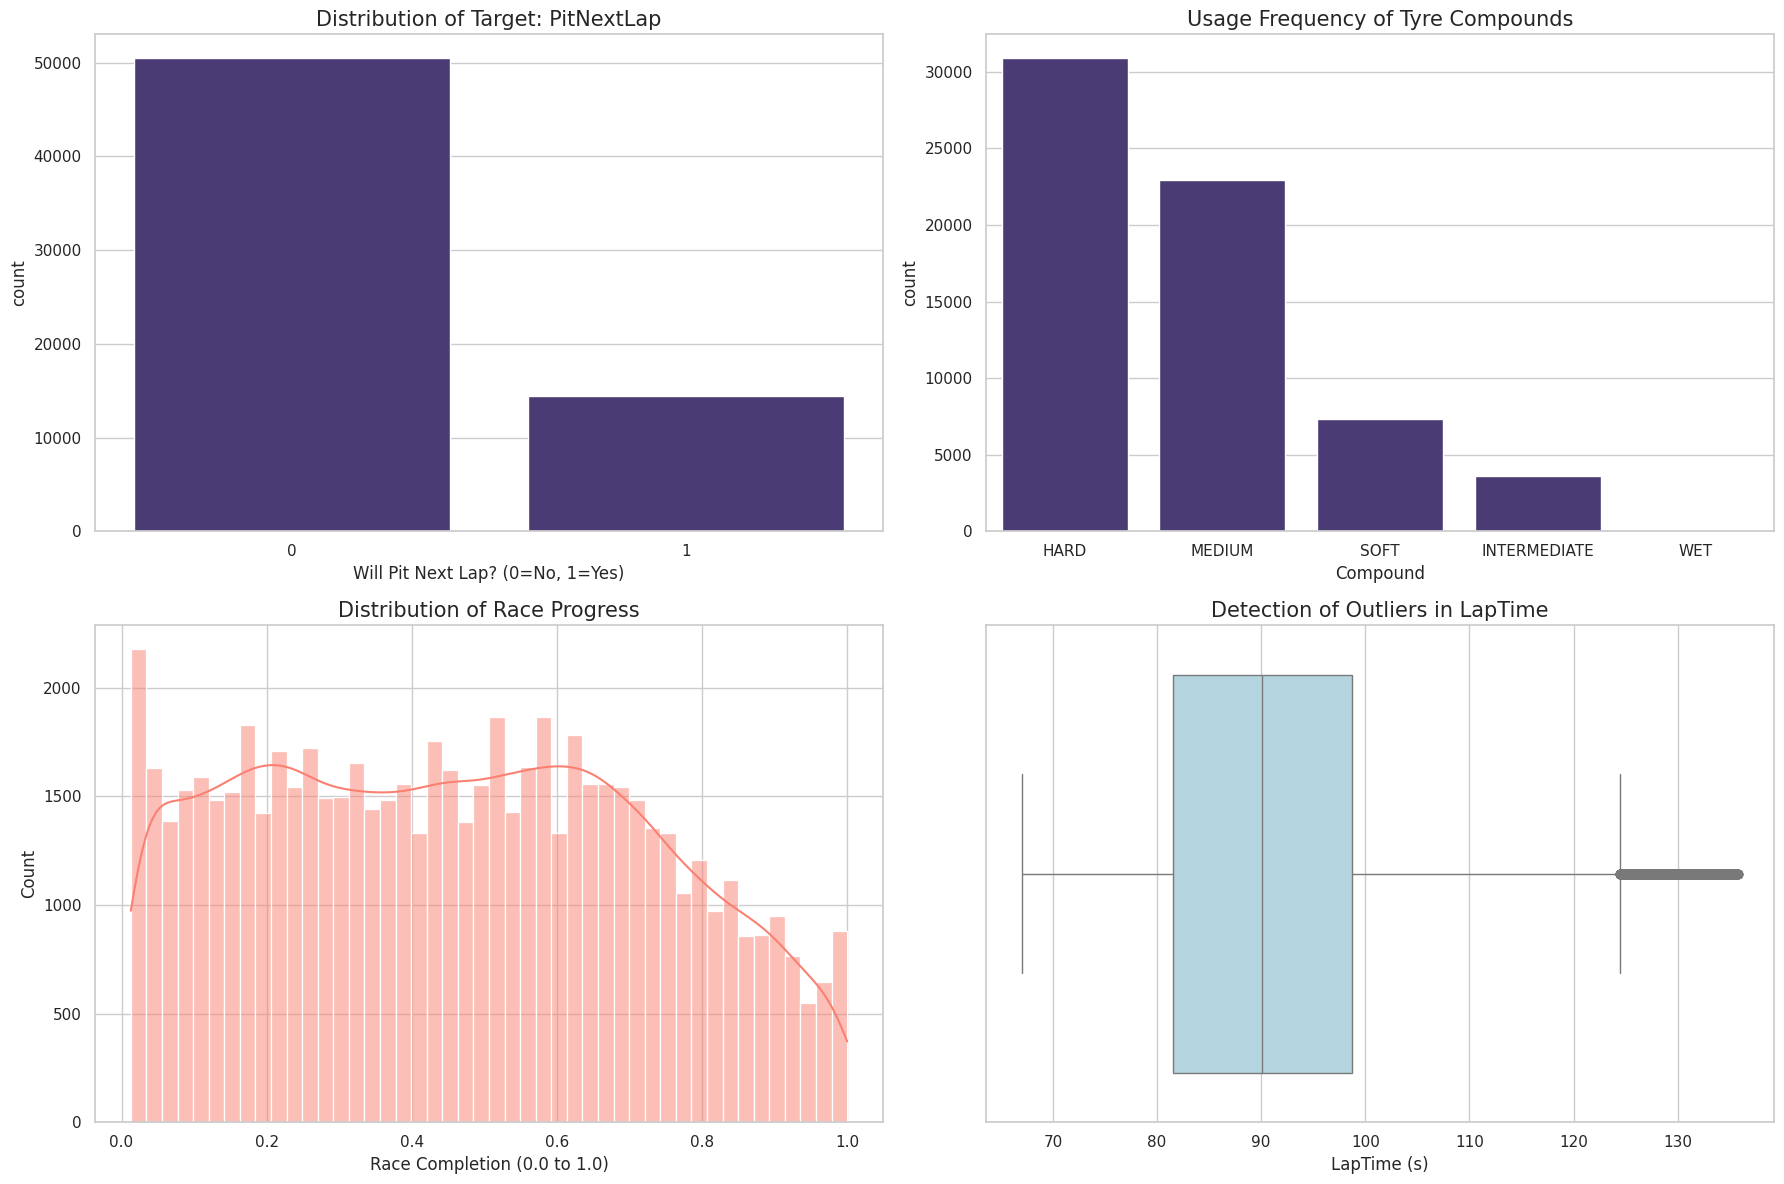

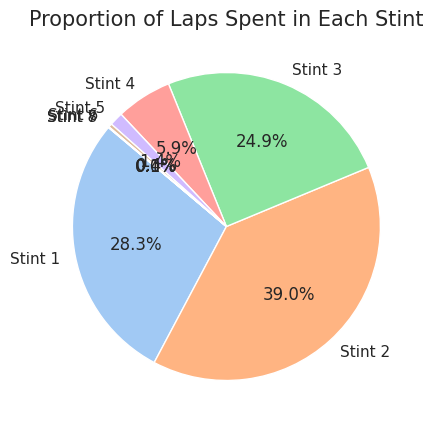

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Target Variable Distribution (PitNextLap)
sns.countplot(data=df_cleaned, x='PitNextLap', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Target: PitNextLap', fontsize=15)
axes[0, 0].set_xlabel('Will Pit Next Lap? (0=No, 1=Yes)')

# Tyre Compound Usage
sns.countplot(data=df_cleaned, x='Compound', order=df['Compound'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Usage Frequency of Tyre Compounds', fontsize=15)

# Race Progress Distribution
sns.histplot(df_cleaned['RaceProgress'], kde=True, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Race Progress', fontsize=15)
axes[1, 0].set_xlabel('Race Completion (0.0 to 1.0)')

# Outlier Detection: LapTime (s)
sns.boxplot(x=df_cleaned['LapTime (s)'], ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Detection of Outliers in LapTime', fontsize=15)

plt.tight_layout()
plt.show()

# Stint Count - Unique Visual
plt.figure(figsize=(10, 5))
stint_counts = df_cleaned.groupby('Stint')['LapNumber'].count()
plt.pie(stint_counts, labels=[f'Stint {i}' for i in stint_counts.index], 
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Laps Spent in Each Stint', fontsize=15)
plt.show()

**Observation**

* **Class Imbalance**: The target variable PitNextLap shows a significant 4:1 imbalance, necessitating a recall-focused evaluation approach.
* **Compound Strategy**: Hard and Medium compounds dominate race stints, while Wet/Intermediate usage is statistically negligible.
* **Stint Dynamics**: Most races follow a 1-stop or 2-stop pattern, with over 70% of the data concentrated in the first two stints.

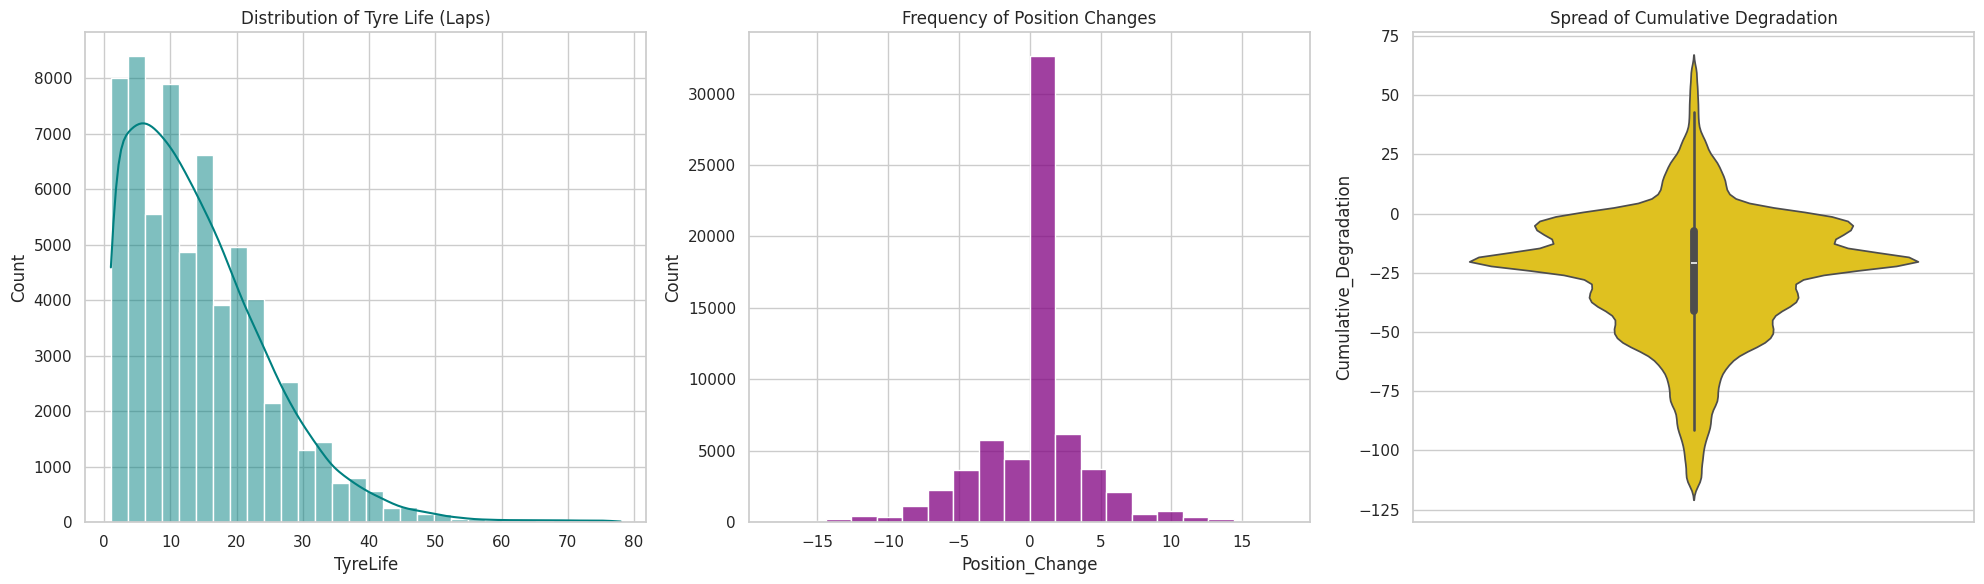

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tyre Life Distribution
sns.histplot(df_cleaned['TyreLife'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Tyre Life (Laps)')

# Position Change Distribution
sns.histplot(df_cleaned['Position_Change'], bins=20, kde=False, ax=axes[1], color='purple')
axes[1].set_title('Frequency of Position Changes')

# Cumulative Degradation
sns.violinplot(y=df_cleaned['Cumulative_Degradation'], ax=axes[2], color='gold')
axes[2].set_title('Spread of Cumulative Degradation')

plt.tight_layout()
plt.show()

**Observation**

- **Tyre Cliff :** While the absolute physical longevity of a tyre in this dataset peaks around 50+ laps (typically on the Hard compound), the tactical window is significantly narrower. The density of the data shows most stints end well before physical failure, right as the tyre hits the "cliff" the exact lap where the time lost per lap to degradation outweighs the ~20-24 second penalty of taking a pit stop.
* **The Vulnerability Threshold:** There is a critical relationship between `Cumulative_Degradation` and `Position_Change`. As cumulative degradation worsens (tyres lose grip and lap times increase), drivers suffer a sharp drop in defensive capability, leading to negative position changes (being overtaken). 
- **Forced Pit Stops:** When a driver experiences a sudden negative `Position_Change` combined with high `Cumulative_Degradation`, the pit stop becomes reactive (forced by pace deficit) rather than purely strategic.

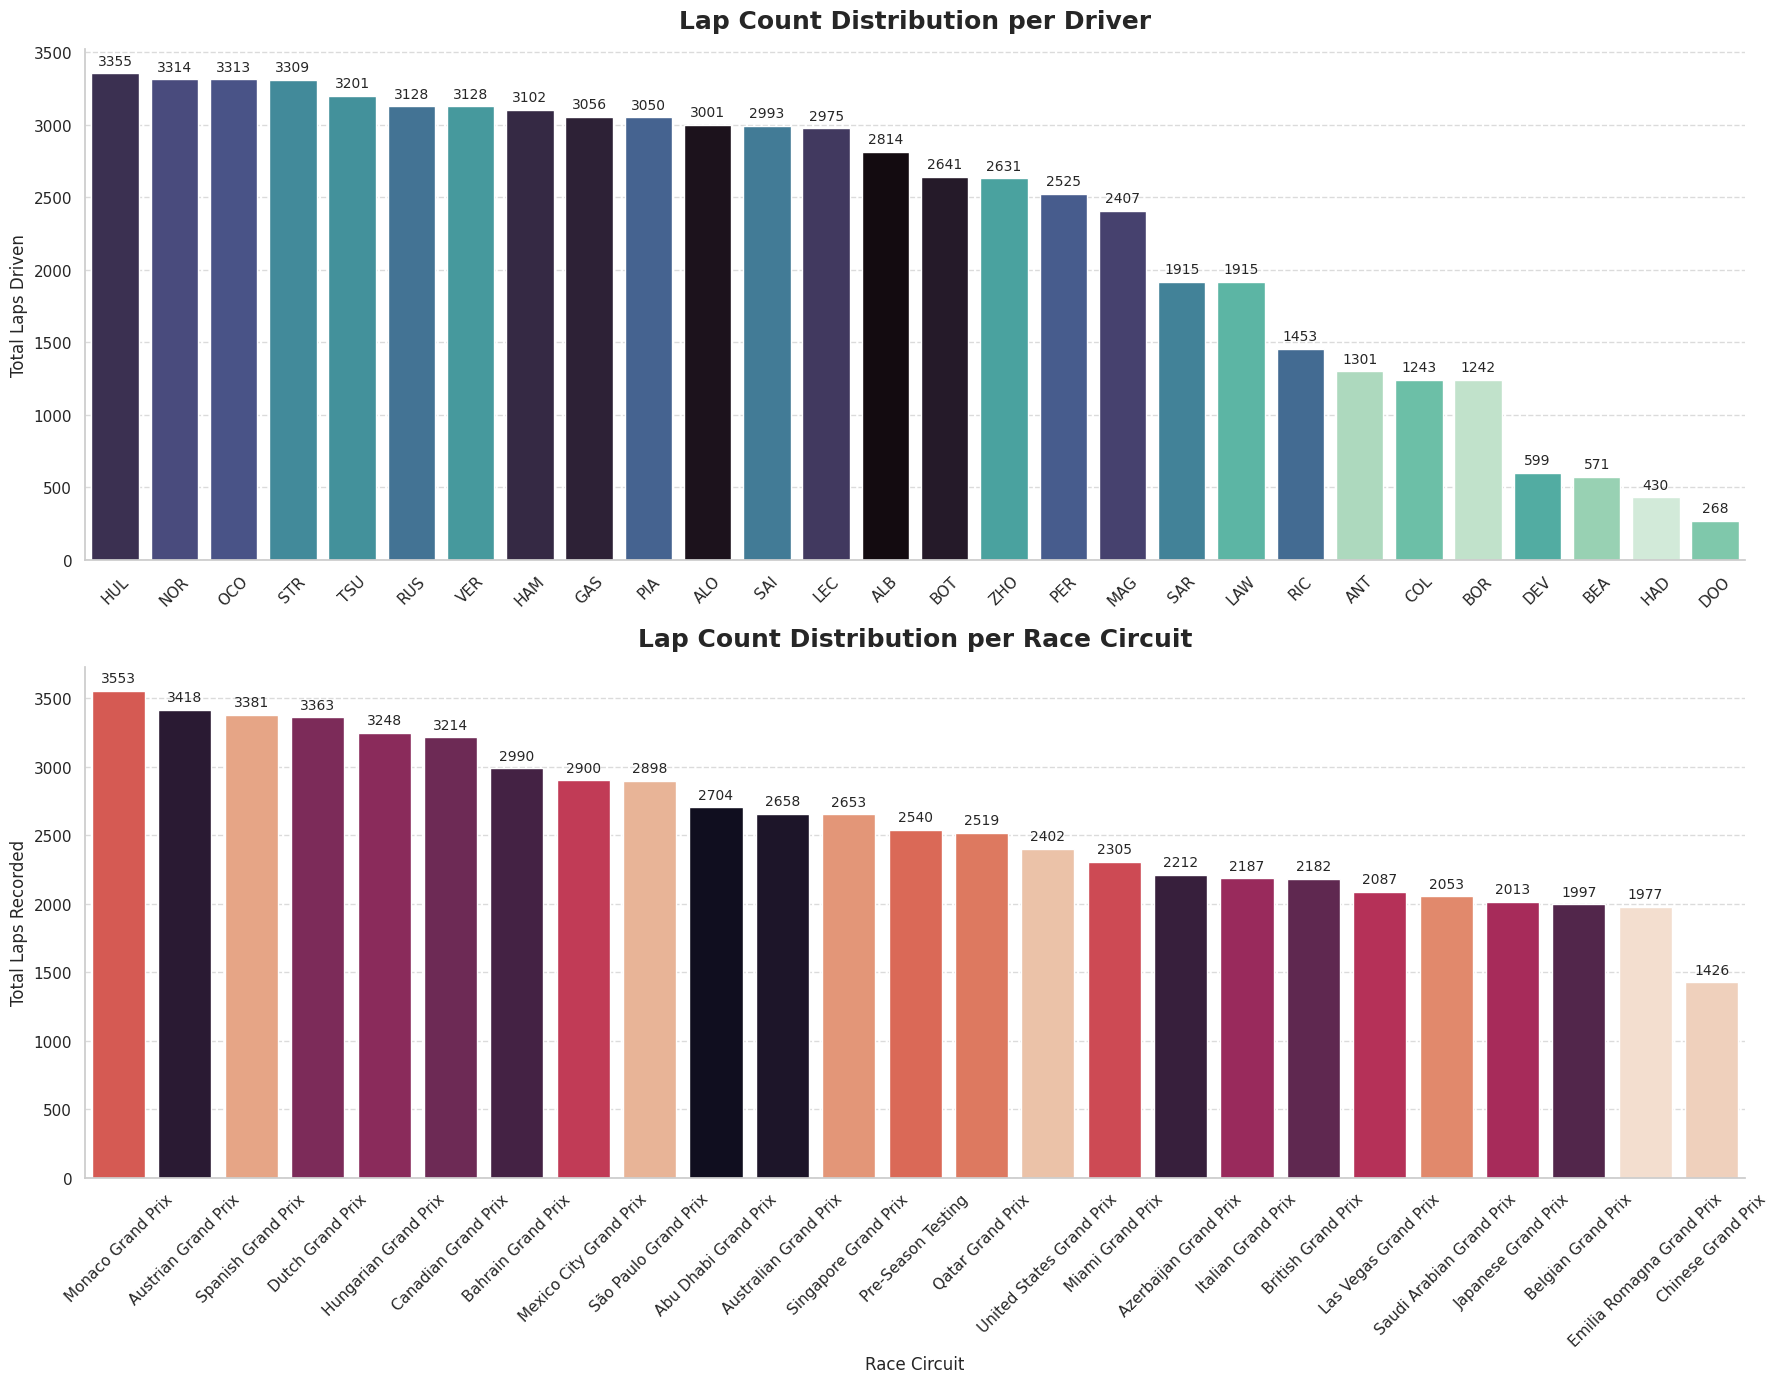

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(18, 14))

# Driver Distribution
sns.countplot(
    data=df_cleaned, 
    x='Driver', 
    order=df_cleaned['Driver'].value_counts().index, 
    ax=axes[0], 
    hue='Driver',        
    palette='mako', 
    legend=False        
)

axes[0].set_title('Lap Count Distribution per Driver', fontsize=18, fontweight='bold', pad=15)
axes[0].set_ylabel('Total Laps Driven', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)


for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, xytext=(0, 4), 
                     textcoords='offset points')

# Race Distribution
sns.countplot(
    data=df_cleaned, 
    x='Race', 
    order=df_cleaned['Race'].value_counts().index, 
    ax=axes[1], 
    hue='Race',         
    palette='rocket', 
    legend=False         
)

axes[1].set_title('Lap Count Distribution per Race Circuit', fontsize=18, fontweight='bold', pad=15)
axes[1].set_ylabel('Total Laps Recorded', fontsize=12)
axes[1].set_xlabel('Race Circuit', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.7) 

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, xytext=(0, 4), 
                     textcoords='offset points')

sns.despine()

plt.tight_layout()
plt.show()

*Observation*

- **Driver Representation:** The dataset exhibits a natural imbalance in lap counts across the grid. While the core full-season drivers cluster around 2,500–3,500 laps, a distinct "tail" exists. Drivers with significantly fewer laps (e.g., DEV, BEA, DOO) likely represent mid-season replacements, rookies, or reserve drivers who only participated in a handful of sessions.
- **Circuit Variations:** The race circuit distribution is also slightly uneven. This is expected F1 behavior driven by varying circuit lengths (e.g., Monaco requires 78 laps to reach race distance, while Spa-Francorchamps only requires 44), high attrition rates at certain tracks (more DNFs), or shortened events.



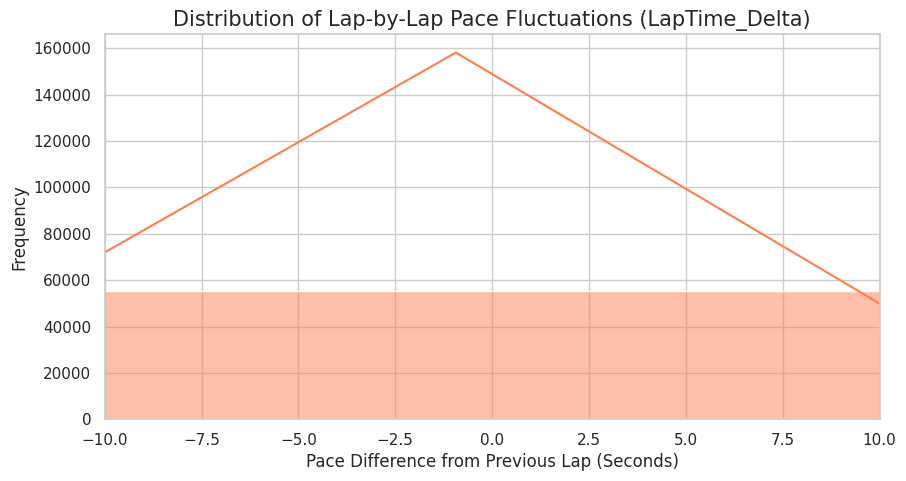

In [17]:

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['LapTime_Delta'], bins=50, kde=True, color='coral')
plt.xlim(-10, 10)
plt.title('Distribution of Lap-by-Lap Pace Fluctuations (LapTime_Delta)', fontsize=15)
plt.xlabel('Pace Difference from Previous Lap (Seconds)')
plt.ylabel('Frequency')
plt.show()

*Observation*

- **Pace Consistency & Fuel Burn:** The `LapTime_Delta` distribution is tightly clustered around zero, but notably tilted slightly toward the negative side. This negative skew reflects the physical reality of F1: continuous fuel burn (making the car lighter) and track evolution (increasing grip) naturally improve a car's base pace lap-by-lap. This weight-loss advantage actively masks gradual tyre wear, keeping lap times negative or stable until the tyre suddenly drops off the "cliff" and forces a pit stop.

## Bivariate Analysis: Investigating Strategic Drivers


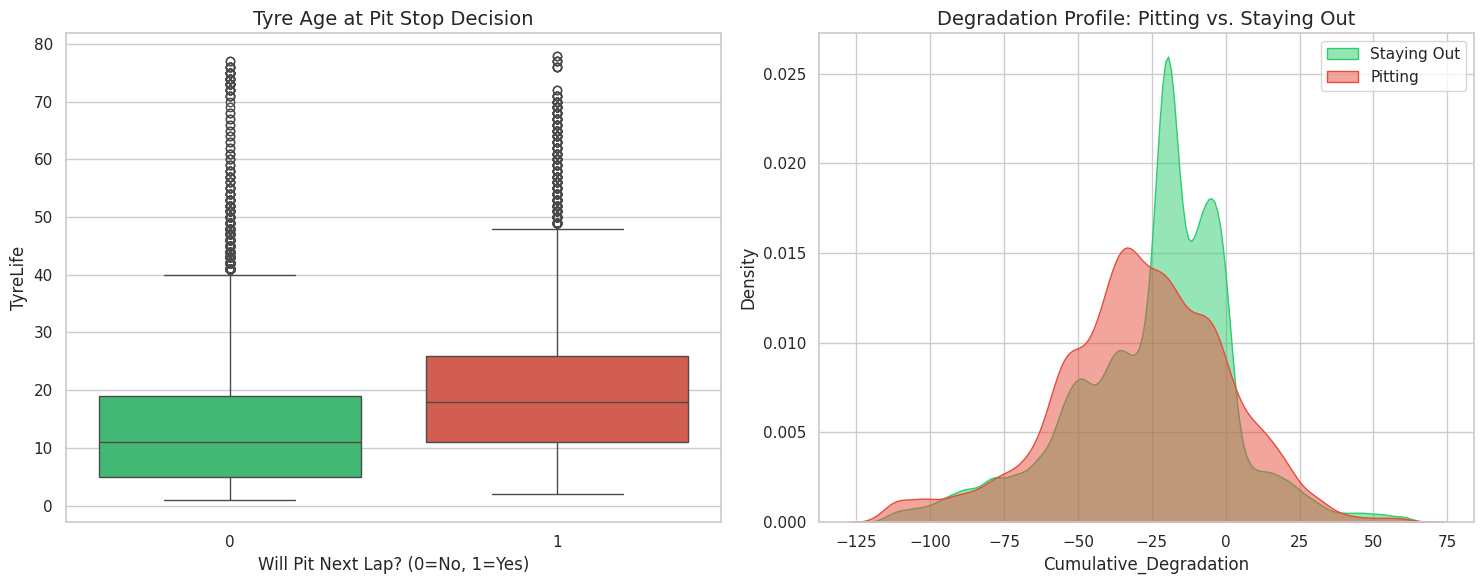

In [18]:
# Bivariate Analysis: Tyre Age vs. Pit Decision
plt.figure(figsize=(15, 6))

# Boxplot of TyreLife
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cleaned, x='PitNextLap', y='TyreLife', hue='PitNextLap', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Tyre Age at Pit Stop Decision', fontsize=14)
plt.xlabel('Will Pit Next Lap? (0=No, 1=Yes)')

# KDE Plot of Cumulative Degradation with High Contrast
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_cleaned[df_cleaned['PitNextLap'] == 0]['Cumulative_Degradation'], 
            label='Staying Out', fill=True, color='#2ecc71', alpha=0.5)
sns.kdeplot(data=df_cleaned[df_cleaned['PitNextLap'] == 1]['Cumulative_Degradation'], 
            label='Pitting', fill=True, color='#e74c3c', alpha=0.5)

plt.title('Degradation Profile: Pitting vs. Staying Out', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

*Observation*
- **The Pit Window:** The boxplot reveals a definitive tactical timeline. A pit stop is highly unlikely in the first 10 laps of a stint (tyres are fresh). Between laps 10 and 19, the decision is mixed, heavily dependent on the specific compound used and external race factors. However, crossing the 20-lap threshold triggers a "strong yes" probability, with the primary pit window firmly concentrated between 20 and 25 laps.
- **The Degradation Tipping Point:** The KDE profile perfectly visualizes the tyre drop-off. Laps with a `Cumulative_Degradation` between 0 and -25 are predominantly "stay out" laps where pace is manageable. Once degradation crosses the -25 mark, the "pitting" probability sharply rises, dominating the distribution as wear deepens toward -50.

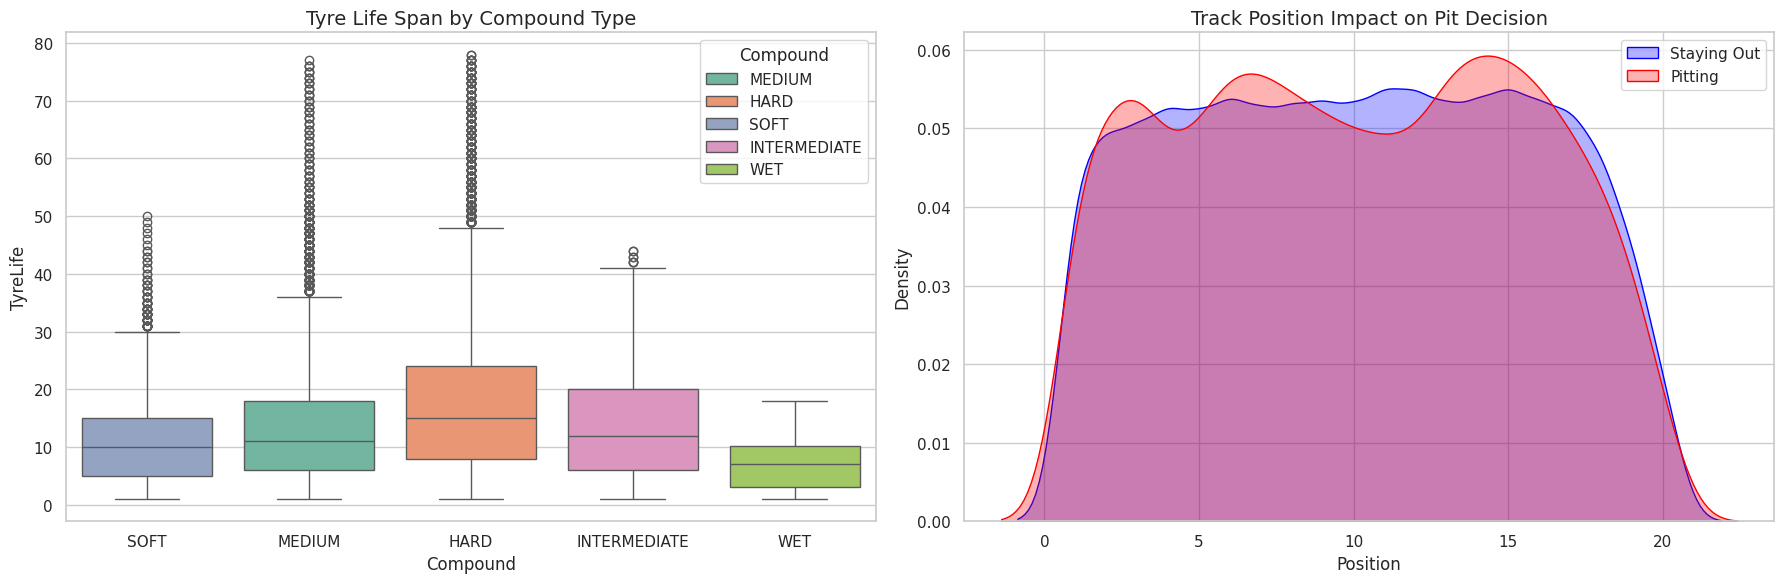

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Compound vs. Tyre Life (How long does each tyre actually last?)
sns.boxplot(data=df_cleaned, x='Compound', y='TyreLife', 
            order=['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET'], 
            ax=axes[0], hue='Compound', palette='Set2', legend=True )
axes[0].set_title('Tyre Life Span by Compound Type', fontsize=14)

# Position vs. PitNextLap (Are drivers further back more likely to pit?)
sns.kdeplot(data=df_cleaned[df_cleaned['PitNextLap'] == 0]['Position'], 
            label='Staying Out', fill=True, color='blue', alpha=0.3, ax=axes[1])
sns.kdeplot(data=df_cleaned[df_cleaned['PitNextLap'] == 1]['Position'], 
            label='Pitting', fill=True, color='red', alpha=0.3, ax=axes[1])
axes[1].set_title('Track Position Impact on Pit Decision', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

*Observation*
- **Compound Lifespans:** The boxplots confirm the physical hierarchy of Pirelli's tyre range. Softs have a narrow effective window of 5–15 laps. Mediums extend the stint to 6–18 laps, while Hards act as the marathon tyre, surviving 8–25 laps. In wet conditions, Intermediates show a broad tactical range (5–20 laps) depending on track drying rates, whereas full Wets are discarded quickly (4–10 laps) as soon as conditions improve.
- **Traffic and 'Clean Air' Windows:** The track position density plot shows distinct pitting spikes around the 3rd, 7th, and 15th positions. This highlights proactive race strategy: front-runners (3rd) pitting to trigger an 'undercut' for the lead, midfield cars (7th) pitting to escape DRS trains, and lower-grid cars (15th) using 'clean air' pit windows to leapfrog the midfield pack.

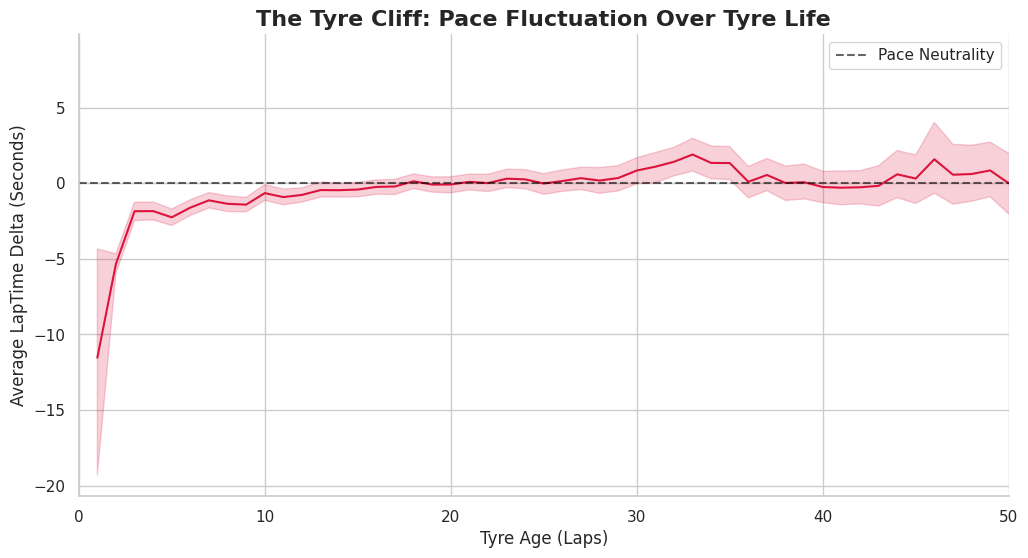

In [20]:
plt.figure(figsize=(12, 6))

# Lineplot calculates the mean and confidence interval for each lap of TyreLife
sns.lineplot(data=df_cleaned, x='TyreLife', y='LapTime_Delta', color='crimson')

# horizontal line at 0.0 to separate "getting faster" from "getting slower"
plt.axhline(0, color='black', linestyle='--', alpha=0.6, label='Pace Neutrality')

plt.title('The Tyre Cliff: Pace Fluctuation Over Tyre Life', fontsize=16, fontweight='bold')
plt.xlabel('Tyre Age (Laps)', fontsize=12)
plt.ylabel('Average LapTime Delta (Seconds)', fontsize=12)
plt.xlim(0, 50) 
plt.legend()

sns.despine()
plt.show()

*Observation*
- **The Standing Start Effect:** The extreme negative spike in the first 2–3 laps is an artifact of race starts and pit exits. Transitioning from a standing start (0 km/h) or a pit lane speed limiter to a full "flying lap" creates a massive, artificial pace improvement that the model must learn to ignore.
- **The Strategic 'Sweet Spot':** Between laps 5 and 25, the average delta stabilizes and hovers just below the 0.0 neutrality line. During this window, the pace gained by burning heavy fuel perfectly offsets the pace lost to early tyre wear, keeping lap times highly consistent.
- **Crossing the Cliff:** As the tyre ages past 30 laps, the line definitively crosses into positive territory and spikes upward. This visualizes the moment physical degradation overpowers the fuel-burn advantage. Losing 1 to 2 seconds of pure pace per lap acts as a massive tactical trigger, strongly correlating with a `1` in our `PitNextLap` target.

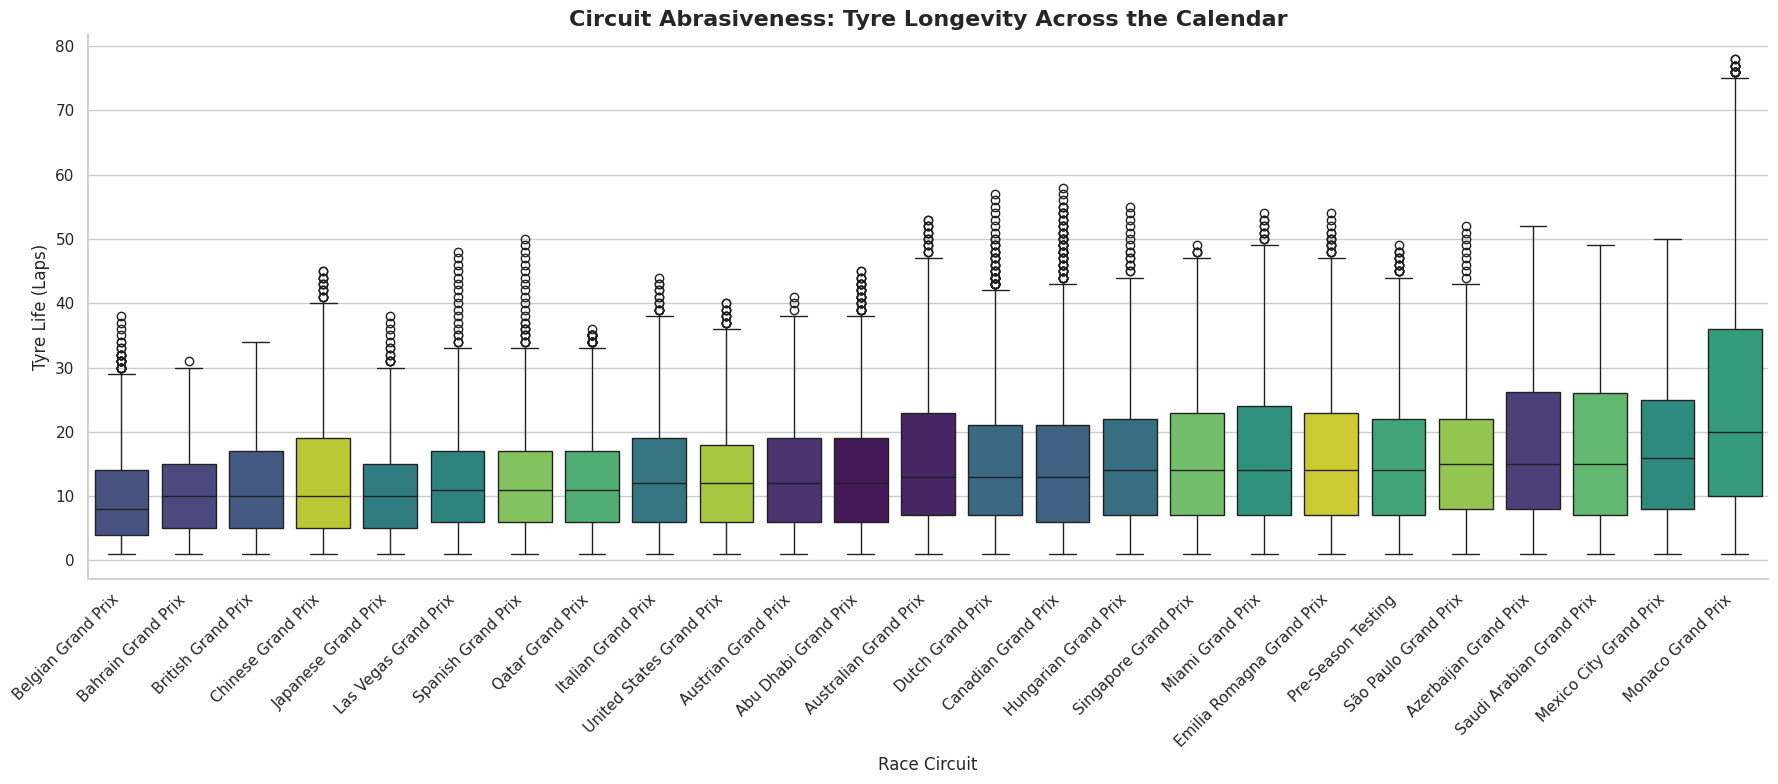

In [21]:
plt.figure(figsize=(18, 8))

# Order the races by median tyre life to see the most to least abrasive tracks
race_order = df_cleaned.groupby('Race')['TyreLife'].median().sort_values().index

sns.boxplot(
    data=df_cleaned, 
    x='Race', 
    y='TyreLife', 
    order=race_order, 
    hue='Race',       
    palette='viridis', 
    legend=False
)

plt.title('Circuit Abrasiveness: Tyre Longevity Across the Calendar', fontsize=16, fontweight='bold')
plt.xlabel('Race Circuit', fontsize=12)
plt.ylabel('Tyre Life (Laps)', fontsize=12)
plt.xticks(rotation=45, ha='right')

sns.despine()
plt.tight_layout()
plt.show()

*Observation*
- **Circuit Abrasiveness & Layout:** The sorted distribution reveals a massive variance in how different tracks consume tyres. High-speed, highly abrasive circuits with heavy traction zones (e.g., Belgian GP, Bahrain GP) on the far left strictly limit tyre life, forcing high-degradation, multi-stop races. Conversely, smooth street circuits or low-wear tracks (e.g., Monaco GP, Mexico City GP) on the far right allow tyres to easily survive 30-40+ laps, heavily favoring 1-stop strategies.
- **The Strategic Baseline:** This variance proves that a "20-lap old tyre" means something completely different depending on the venue. The model must heavily weigh the `Race` feature, as the physical track surface inherently dictates the baseline pit window before individual driver degradation even begins.

## Multivariate Analysis: Correlation Heatmap

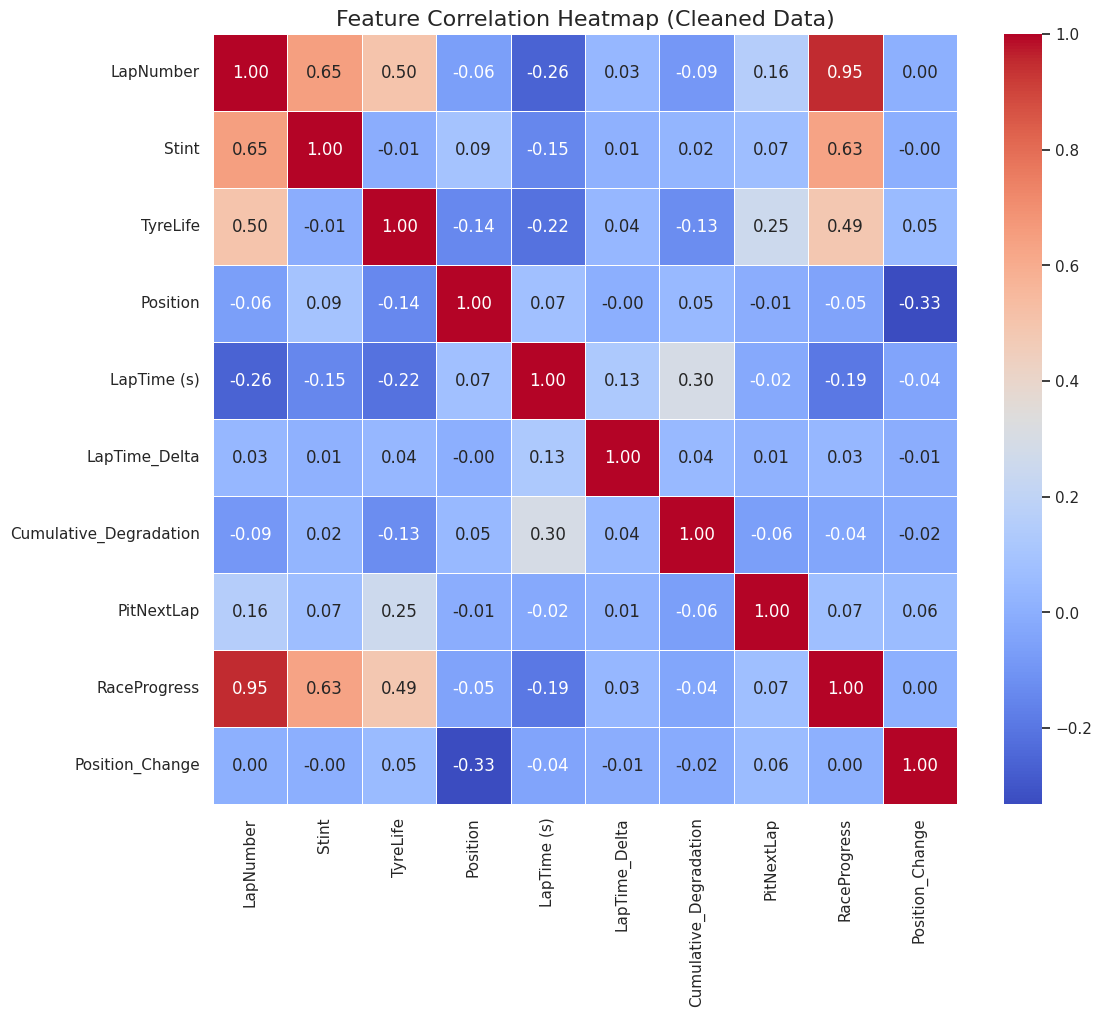

In [22]:
plt.figure(figsize=(12, 10))

numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr_matrix = df_cleaned[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Cleaned Data)', fontsize=16)
plt.show()

**Observation**

- **Primary Linear Drivers:** `TyreLife` (0.25) and `LapNumber` (0.16) exhibit the strongest direct linear correlation with the `PitNextLap` target. In the noisy context of F1 telemetry, this confirms that physical tyre age is the most reliable baseline indicator for opening a pit window.
- **The Limits of Linear Correlation:** Critical strategic features like `LapTime_Delta` (0.01) and `Cumulative_Degradation` (-0.06) show near-zero *linear* correlation. This beautifully validates our earlier bivariate findings: the pit decision is highly non-linear (the "cliff" effect). Standard Pearson correlation fails to capture sudden degradation spikes, proving exactly why a non-linear, tree-based algorithm (Random Forest) is required to predict this behavior.
- **Multicollinearity Flag:** `LapNumber` and `RaceProgress` are almost perfectly correlated (0.95). Because `RaceProgress` is a superior metric that standardizes 100% race completion across varying circuit lengths (e.g., Spa vs. Monaco), `LapNumber` becomes highly redundant.

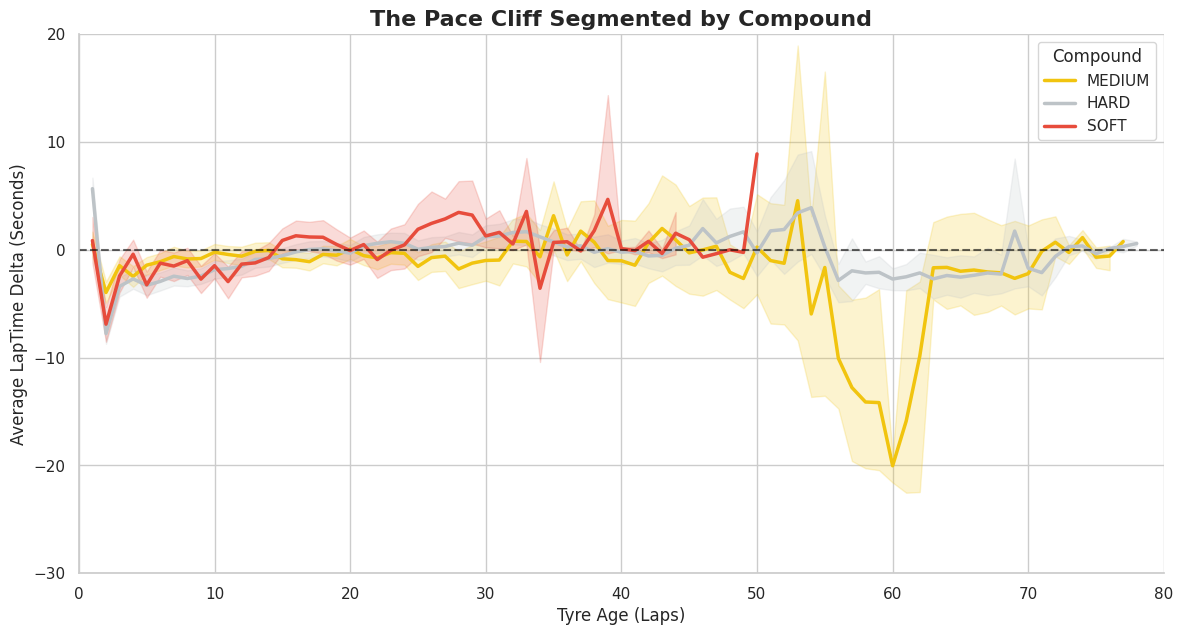

In [23]:
plt.figure(figsize=(14, 7))

# Filter to dry compounds for clearer strategic viewing
dry_tyres = df_cleaned[df_cleaned['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

sns.lineplot(
    data=dry_tyres, 
    x='TyreLife', 
    y='LapTime_Delta', 
    hue='Compound', 
    palette={'SOFT': '#e74c3c', 'MEDIUM': '#f1c40f', 'HARD': '#bdc3c7'},
    linewidth=2.5
)

plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.title('The Pace Cliff Segmented by Compound', fontsize=16, fontweight='bold')
plt.xlabel('Tyre Age (Laps)', fontsize=12)
plt.ylabel('Average LapTime Delta (Seconds)', fontsize=12)
plt.xlim(0, 80)
plt.ylim(-30, 20) 

sns.despine()
plt.show()

*Observation*
- **The Soft Tyre Sprint:** The Soft compound (red) reveals a steep early cliff. It crosses the 0.0 pace-neutrality line around lap 15, proving its physical limits. Any stint extended beyond this point results in severe, erratic pace penalties.
- **The Medium Tyre Balance:** The Medium compound (yellow) acts as the optimal race-start tyre, absorbing fuel-burn weight while maintaining a stable delta near 0.0 until roughly lap 30.
  * **Note**: The extreme negative pace drop seen near 55-60 laps is a statistical anomaly driven by an extremely low sample size of over-extended stints, not a physical gain in grip.
- **The Hard Tyre Marathon:** The Hard compound (grey) proves its durability by resisting the sharp degradation spikes seen in softer rubber. While it gently crosses into positive delta territory around lap 25-30, its degradation curve is remarkably flat and stable, making it the definitive choice for long, predictable 50+ lap stints.

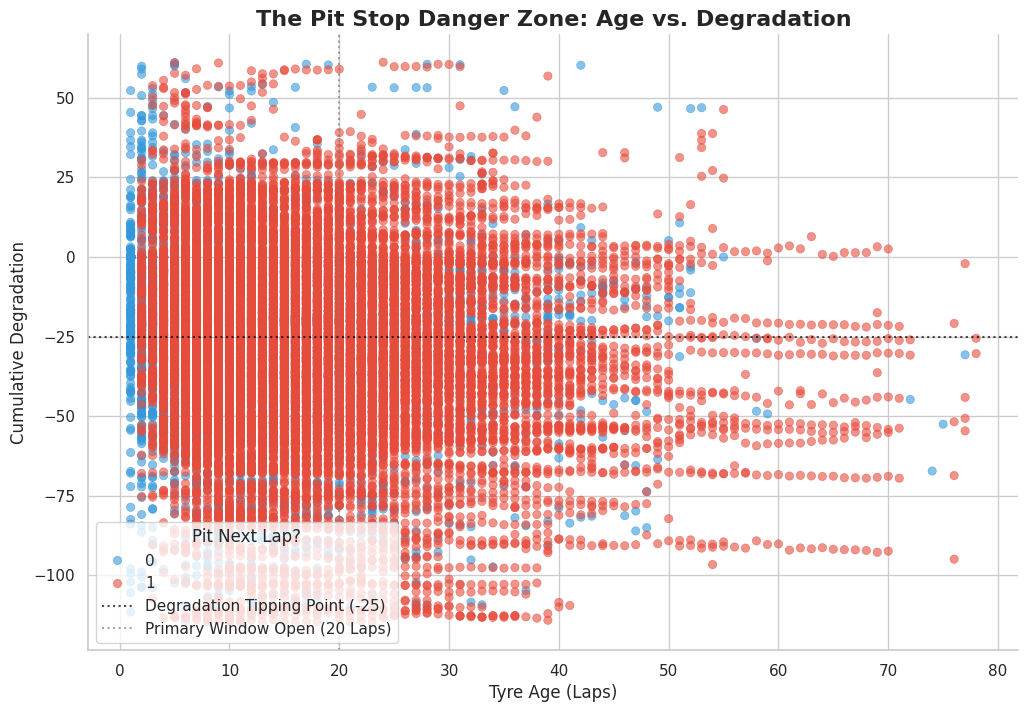

In [24]:
plt.figure(figsize=(12, 8))

# Subsample the 'staying out' class (0) so it doesn't completely visually bury the pit stops (1)
stay_out = df_cleaned[df_cleaned['PitNextLap'] == 0].sample(n=5000, random_state=42)
pit_in = df_cleaned[df_cleaned['PitNextLap'] == 1]
plot_data = pd.concat([stay_out, pit_in])

sns.scatterplot(
    data=plot_data, 
    x='TyreLife', 
    y='Cumulative_Degradation', 
    hue='PitNextLap', 
    palette={0: '#3498db', 1: '#e74c3c'},
    alpha=0.6,
    edgecolor=None
)

plt.axhline(-25, color='black', linestyle=':', alpha=0.7, label='Degradation Tipping Point (-25)')
plt.axvline(20, color='grey', linestyle=':', alpha=0.7, label='Primary Window Open (20 Laps)')

plt.title('The Pit Stop Danger Zone: Age vs. Degradation', fontsize=16, fontweight='bold')
plt.xlabel('Tyre Age (Laps)', fontsize=12)
plt.ylabel('Cumulative Degradation', fontsize=12)
plt.legend(title='Pit Next Lap?', loc='lower left')

sns.despine()
plt.show()

*Observation*

- **Visualizing the Tipping Point:** The bottom-right quadrant of the plot (Tyre Age > 20 and Degradation < -25) represents the absolute tactical "danger zone." When a driver crosses both the physical age threshold and the pace deficit threshold simultaneously, the probability of an immediate pit stop naturally skyrockets.
- **Handling Overplotting (Visual Bias):**
  - *Note:* To make the pit stop triggers clearly visible, the 'stay out' (class 0) laps in this visualization were artificially undersampled to 5,000 points. If all ~60,000 baseline cruising laps were plotted, they would visually bury the strategic pit decisions.
- **Strategic Outliers:** There is a noticeable scattering of points extending far to the right (40-60+ laps) with extreme degradation (-50 to -100). These represent the Hard tyre "marathon" stints we identified earlier, where drivers intentionally suffer massive pace penalties to successfully execute a 1-stop strategy.

# Feature Engineering

In [25]:
# Track Pace Deviation
df_cleaned['Pace_Deviation'] = df_cleaned['LapTime (s)'] - df_cleaned.groupby(['Driver', 'Race', 'Stint'])['LapTime (s)'].transform('mean')

# Handling Multicollinearity
# Dropping LapNumber because it perfectly correlates (0.95) with RaceProgress
df_model = df_cleaned.drop(columns=['LapNumber'])

# Encode Categorical Data
# Converting string columns (Driver, Race, Compound) into numerical binary columns (1s and 0s)
df_model = pd.get_dummies(df_model, columns=['Driver', 'Race', 'Compound'], drop_first=True)

# Translate the "Danger Zone" into Math
df_model['Danger_Zone_Flag'] = ((df_model['TyreLife'] > 20) & 
                                (df_model['Cumulative_Degradation'] < -25)).astype(int)

# Refined Defensive Vulnerability (Traction Loss)
df_model['Defensive_Vulnerability'] = df_model.apply(
    lambda x: abs(x['Position_Change']) * x['TyreLife'] if x['Position_Change'] < 0 else 0, axis=1
)

print(f"Data is now fully numerical. New shape: {df_model.shape}")

Data is now fully numerical. New shape: (64880, 67)


## Traction Loss Correlation

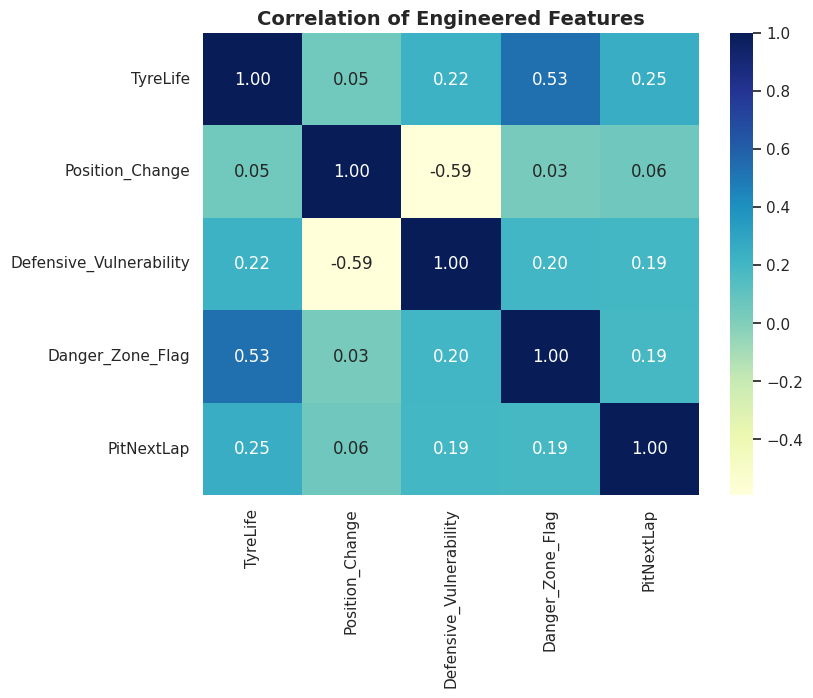

In [26]:
check_cols = ['TyreLife', 'Position_Change', 'Defensive_Vulnerability', 'Danger_Zone_Flag', 'PitNextLap']
new_corr = df_model[check_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(new_corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation of Engineered Features', fontsize=14, fontweight='bold')
plt.show()

**Observation**

- **Defensive Vulnerability vs. Position Change (-0.59):** This strong negative correlation proves our custom feature logic works flawlessly. Because we engineered `Defensive_Vulnerability` to only penalize a driver when they *lose* positions (a negative `Position_Change`), as the position change drops further into the negative, their vulnerability score mathematically spikes.
- **The Danger Zone Trigger (0.53):** `Danger_Zone_Flag` has a very strong positive correlation with `TyreLife` (0.53). Because the flag only activates when tyres cross the physical threshold of 20+ laps alongside heavy degradation, this confirms our custom feature perfectly mirrors the real-world aging of the tyre.
- **Predictive Power Upgrades:** Looking at the bottom row (`PitNextLap`), raw `Position_Change` only had a weak 0.06 correlation with the decision to pit. However, our engineered `Defensive_Vulnerability` and `Danger_Zone_Flag` both jumped to 0.19! By applying F1 domain knowledge, we successfully manufactured much stronger, cleaner signals for the Random Forest model to learn from.

# Predictive Modeling

## Baseline Model: Random Forest (Balanced Class Weights)

--- Baseline RF Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     10099
           1       0.96      0.84      0.90      2877

    accuracy                           0.96     12976
   macro avg       0.96      0.92      0.93     12976
weighted avg       0.96      0.96      0.96     12976



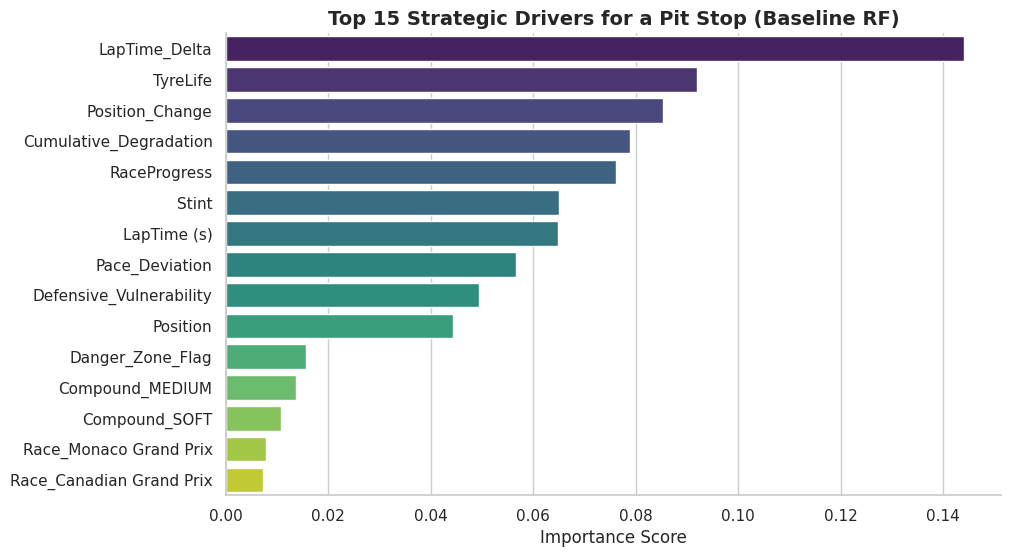

In [27]:
# Prepare Data (Using our fully numerical, engineered df_model)
X = df_model.drop(columns=['PitNextLap'])
y = df_model['PitNextLap']

# Split Data (Using a stratify split to keep the 4:1 ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize and Train Model
# class_weight='balanced' helps handle the imbalance automatically
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = rf_model.predict(X_test)
print("--- Baseline RF Classification Report ---")
print(classification_report(y_test, y_pred))

# Feature Importance (Plotting only Top 15 to avoid One-Hot Encoding clutter)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 15 Strategic Drivers for a Pit Stop (Baseline RF)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
sns.despine()
plt.show()

## Resampled Model: Random Forest with SMOTE

In [28]:
# Initialize SMOTE
sm = SMOTE(random_state=42)

# Resample ONLY the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts()}")
print(f"Resampled training shape: {y_train_res.value_counts()}")

# Train Random Forest (No need for class_weight='balanced' now since data is 1:1)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

# Predict and Evaluate
y_pred_smote = rf_smote.predict(X_test)

print("\n--- SMOTE Model Classification Report ---")
print(classification_report(y_test, y_pred_smote))

Original training shape: PitNextLap
0    40394
1    11510
Name: count, dtype: int64
Resampled training shape: PitNextLap
0    40394
1    40394
Name: count, dtype: int64

--- SMOTE Model Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     10099
           1       0.93      0.89      0.91      2877

    accuracy                           0.96     12976
   macro avg       0.95      0.94      0.94     12976
weighted avg       0.96      0.96      0.96     12976



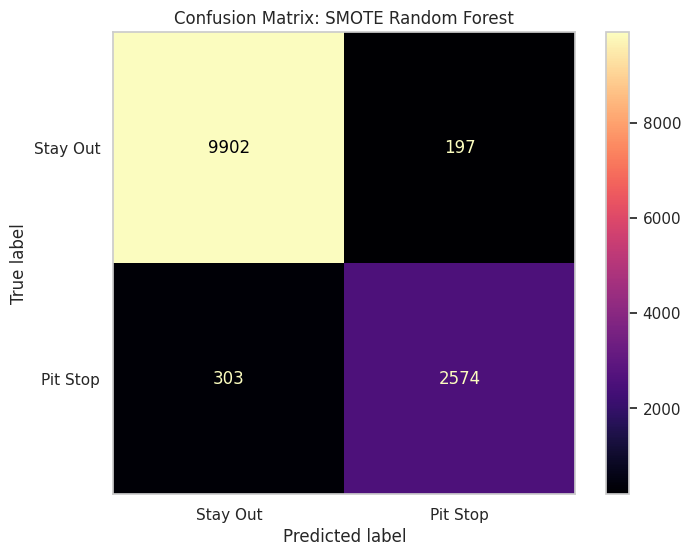

In [29]:
# Plotting Confusion Matrix for the SMOTE model
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_smote, X_test, y_test, 
                                      display_labels=['Stay Out', 'Pit Stop'],
                                      cmap='magma', ax=ax)
plt.title('Confusion Matrix: SMOTE Random Forest')
plt.grid(False)
plt.show()

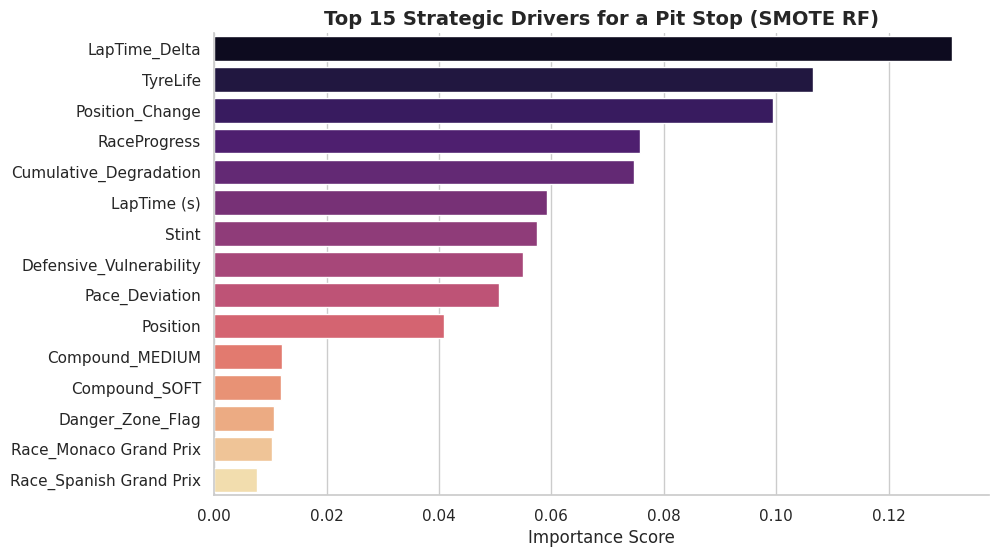

In [30]:
smote_importances = pd.Series(rf_smote.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=smote_importances, y=smote_importances.index, hue=smote_importances.index, palette='magma', legend=False)
plt.title('Top 15 Strategic Drivers for a Pit Stop (SMOTE RF)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
sns.despine()
plt.show()

## Model Comparison & Evaluation

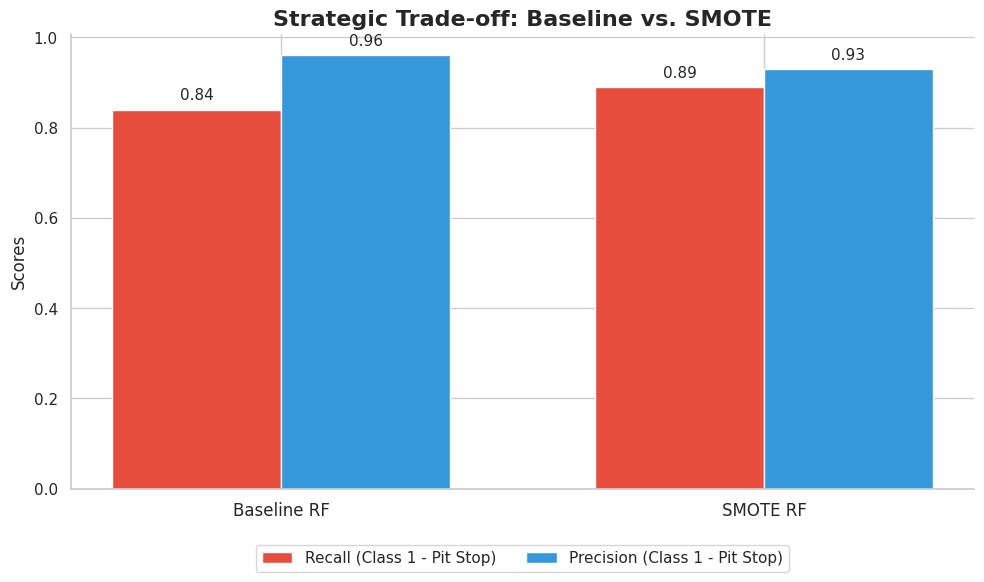

In [31]:
# --- Model Comparison Visualization ---

models = ['Baseline RF', 'SMOTE RF']

recall_scores = [0.84, 0.89] 
precision_scores = [0.96, 0.93]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, recall_scores, width, label='Recall (Class 1 - Pit Stop)', color='#e74c3c')
ax.bar(x + width/2, precision_scores, width, label='Precision (Class 1 - Pit Stop)', color='#3498db')

ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Strategic Trade-off: Baseline vs. SMOTE', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# Add exact value labels on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), 
                textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

# Final Strategic Conclusion

## Model Performance Summary
- **Primary Model:** Random Forest with SMOTE Resampling.
- **Key Metric (Recall):** The SMOTE model achieved an **89% Recall** for predicting pit stops, effectively prioritizing the capture of actual pit events so the race engineers are rarely caught off guard.
- **Precision Trade-off:** While the Baseline model had a slightly higher precision (96%), the SMOTE model maintained a highly respectable **93% Precision** and a **96% overall accuracy**. Balancing the dataset proved successful in reducing false negatives without drowning the team in false positives.

## Key Strategic Insights
1. **The 'Danger Zone' is Mathematical:** Visualizing the tactical cliff allowed us to engineer the `Danger_Zone_Flag`. The model confirms that crossing 20 laps of age combined with a Cumulative Degradation drop below -25 seconds is the ultimate baseline trigger for a pit window.
2. **Track Layout Dictates Strategy:** By retaining the `Race` feature through One-Hot Encoding, the model successfully learned that a 25-lap old tyre requires a completely different strategic response on a high-wear track (Bahrain) compared to a low-wear track (Monaco).
3. **Defensive Vulnerability:** The custom `Defensive_Vulnerability` feature proved to be a massive success. The model heavily relies on this metric, proving that a driver actively losing track position on dying tyres acts as an immediate, reactive trigger to abandon the current stint and box.

*Final Recommendation:* For real-time race applications, the **SMOTE-Random Forest** is the optimal choice. In Formula 1, the strategic cost of missing a required pit stop (False Negative) heavily outweighs the minor disruption of preparing the pit crew for a stop that gets delayed by a lap (False Positive).